In [1]:
import pandas as pd
import os
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from utils import get_partition_distances
DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)

In [2]:


splits_path = "./data/6_sim_folds/"
splits_list = os.listdir(splits_path)
splits_list.sort()

splits_list = splits_list[:-1]

splits = {}
for split in splits_list:
    splits[split] = pd.read_csv(splits_path+split)

save_path = "./images/6_sim_folds/no_boostrap/"

In [3]:
print(splits[splits_list[0]].head(2))
dist.head(2)

   fold_name  fold_number partition                              id
0          0            0     train  16s_C.reinhardtii.mito_domain3
1          0            0     train         srp_Kluy.lact._CR382126


id,5s_Acholeplasma-laidlawii-1,5s_Acidovorax-temperans-1,tmRNA_Stre.gord._TRW-29390_1-349,tRNA_tdbR00000055-Schizosaccharomyces_pombe-4896-Glu-3UC,srp_List.mono._U15684,5s_Methanothermobacter-thermautotrophicus-6,srp_Vibr.fisc._CP000020,srp_Baci.thur._D11412,grp1_a.I1.m.M.grisea.B2.ND1,5s_Saprospira-grandis-1,...,RNaseP_M.avium,tRNA_tdbR00000521-Bos_taurus-9913-Ini-CAU,grp1_a.I1.e.P.pachydermus.C1.SSU.943,5s_Pseudomonas-stutzeri-2,16s_T.maritima_domain3,5s_Bacillus-cereus-6,srp_Myco.aviu._AE016958,tmRNA_Heli.pylo._AE001503_1-383,5s_Triticum-aestivum-1,5s_Streptomyces-violaceus-1
id,,,,,,,,,,,,,,,,,,,,,
5s_Acholeplasma-laidlawii-1,0.000000,0.130435,0.805158,0.562500,0.799283,0.265625,0.776786,0.756458,0.782456,0.173554,...,0.763819,0.625000,0.795918,0.150000,0.817734,0.140351,0.696429,0.806789,0.200000,0.216667
5s_Acidovorax-temperans-1,0.130435,0.000000,0.819484,0.591304,0.802867,0.179688,0.747826,0.752768,0.778947,0.132231,...,0.756281,0.652174,0.798469,0.108333,0.815271,0.130435,0.756522,0.814621,0.191667,0.125000


In [4]:
folds = splits[splits_list[1]].fold_number.unique()
folds.sort()
folds

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [5]:
for split in splits_list:
    splits[split]["partition"] = splits[split]["partition"].apply(
        lambda x: "train" if x in ["train", "valid"] else "test"
    )
parts = list(splits[split].partition.unique())

In [6]:
splits[splits_list[0]].partition.unique()

array(['train', 'test'], dtype=object)

In [7]:
# parts = splits[split].partition.unique()
dfs = {split : {s: {p: pd.DataFrame() for p in parts} for s in parts} for split in splits_list}
for split in splits_list:
    for p1 in parts:
        for p2 in parts:
            dfs[split][p1][p2] = get_partition_distances(dist, splits[split], 0, p1, p2)
            print(f"split {split} - {p1} vs {p2}: {dfs[split][p1][p2].shape}")

split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv - train vs train: (4, 4)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv - train vs test: (4, 1)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv - test vs train: (1, 4)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv - test vs test: (1, 1)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv - train vs train: (107, 107)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv - train vs test: (107, 12)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv - test vs train: (12, 107)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv - test vs test: (12, 12)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim50-fold.csv - train vs train: (233, 233)
split archiveII_similars_splits_less_than_512_k10_NOboostrap_sim50-fold.csv - train

In [8]:
stats = {"split": [], "min": [],"mean": [],"max": [] }
for split in splits_list:
    A = dfs[split]["train"]["test"].values
    stats["split"].append(split[44:-9])
    stats["min"].append(np.nanmin(A))
    stats["mean"].append(np.nanmean(A))
    stats["max"].append(np.nanmax(A))
df_stats = pd.DataFrame(stats)
df_stats

,split,min,mean,max
0,NOboostrap_sim30,0.648148,0.726022,0.759259
1,NOboostrap_sim40,0.195122,0.682625,1.151515
2,NOboostrap_sim50,0.089552,0.705109,1.174242
3,NOboostrap_sim60,0.014286,0.722493,1.247525
4,NOboostrap_sim70,0.000000,0.716160,1.272727
5,NOboostrap_sim80,0.000000,0.710202,1.292929
6,NOboostrap_sim90,0.000000,0.708194,1.328671


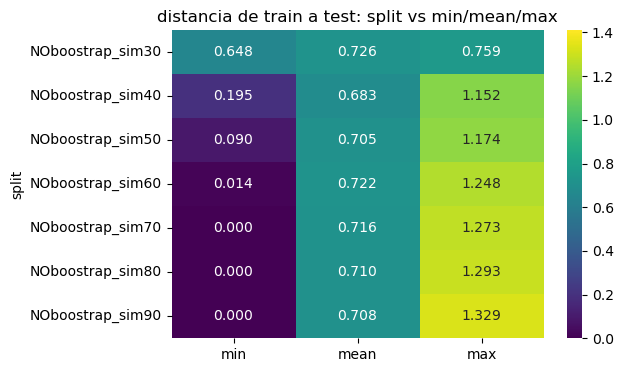

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_stats.set_index("split"),
    annot=True, fmt=".3f",
    cmap="viridis",
    vmin=0, vmax=1.41
)
plt.title("distancia de train a test: split vs min/mean/max")
plt.ylabel("split")
plt.savefig(save_path+"heatmap_stats.pdf")
plt.show()


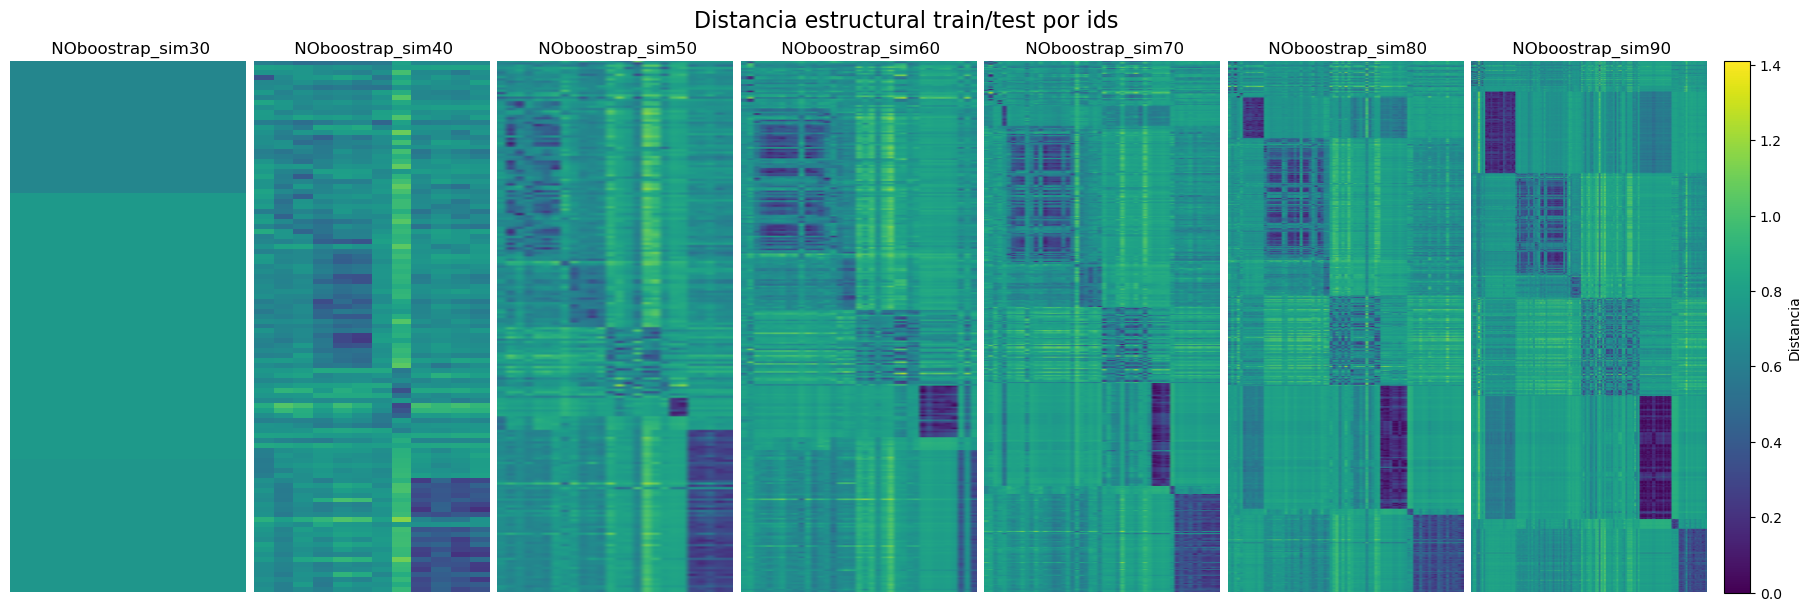

In [10]:

fig, axes = plt.subplots(1, 7, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for i,split in enumerate(splits_list):
    mat = dfs[split]['train']['test'].values
    im = axes[i].imshow(mat, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[i].set_title(f" {split[44:-9]}")
    axes[i].axis('off')  # quita los ticks/labels

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distancia")

plt.suptitle("Distancia estructural train/test por ids", fontsize=16)
plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


In [11]:
from utils import plot_heatmap_idsxfam
plot_heatmap_idsxfam(dfs, splits, save_path,SAVE=False)

KeyError: 'id'

In [11]:
dfs_dists = {}

for split in splits_list:
    rows = []
    for part1, dic in dfs[split].items():
        for part2, mat in dic.items():
            # solo analizamos train/test (part1 != part2)
            if part1 != part2:
                vals = mat.to_numpy().ravel()
                rows.extend({
                    "part1": part1,
                    "part2": part2,
                    "dist": float(v)
                } for v in vals)

    dfs_dists[split] = pd.DataFrame(rows)

# ejemplo: muestro 5 filas
dfs_dists[split].sample(5)


,part1,part2,dist
198823,test,train,0.569966
217222,test,train,0.746575
178136,test,train,0.191667
117236,train,test,0.792079
167022,test,train,0.814570


/tmp/ipykernel_1713995/165005061.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_splits)
/tmp/ipykernel_1713995/165005061.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


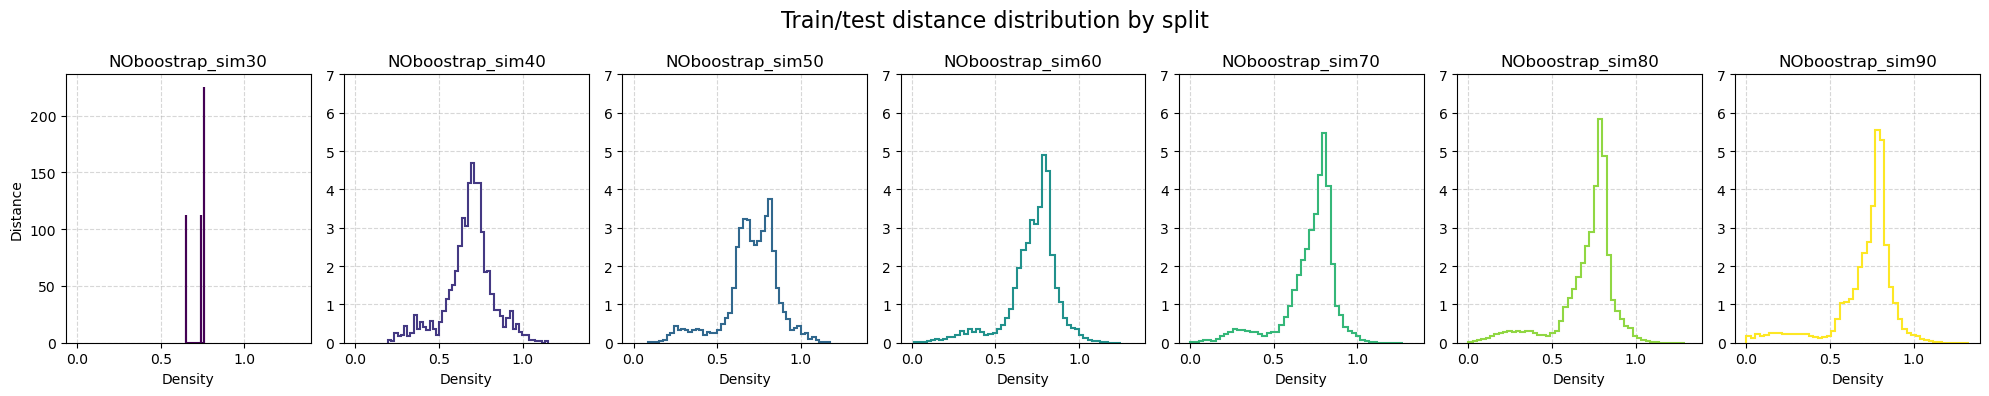

In [15]:


n_splits = len(splits_list)
cmap = cm.get_cmap('viridis', n_splits)
colors = [cmap(i) for i in range(n_splits)]

fig, axes = plt.subplots(1, n_splits, figsize=(20, 4), constrained_layout=True, sharex=True)

for i, split in enumerate(splits_list):
    df = dfs_dists[split]
    axes[i].hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5
    )
    axes[i].set_title(f"{split[44:-9]}")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Density")
    axes[i].grid(True, ls="--", alpha=0.5)
    if i != 0:
        axes[i].set_ylim(0, 7)

axes[0].set_ylabel("Distance")
plt.suptitle("Train/test distance distribution by split", fontsize=16)
plt.tight_layout()
plt.savefig(save_path+"hist_subplots.pdf")
plt.show()


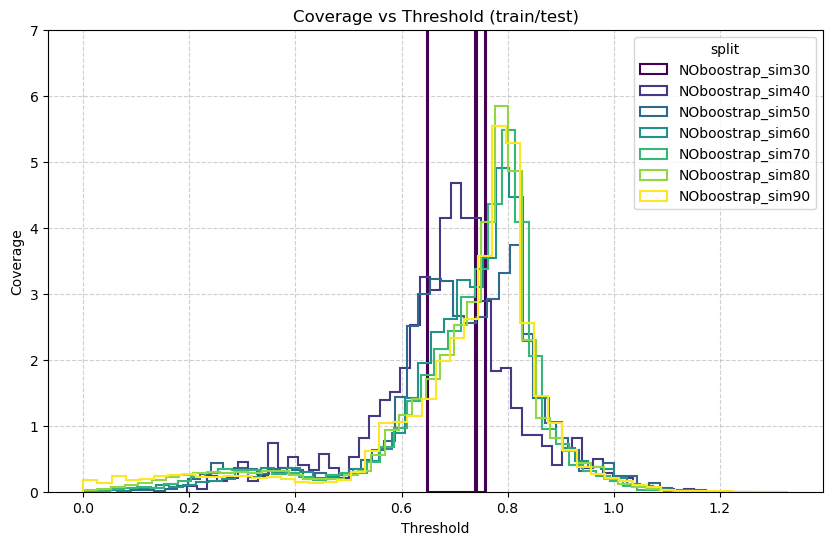

In [13]:
plt.figure(figsize=(10, 6))

for i, split in enumerate(splits_list):
    df = dfs_dists[split]
    plt.hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5,
        label=f"{split[44:-9]}"
    )

plt.title("Coverage vs Threshold (train/test)")
plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.grid(True, ls="--", alpha=0.6)
plt.ylim(0, 7)
plt.legend(title="split")
plt.savefig(save_path+"hist.pdf")
plt.show()


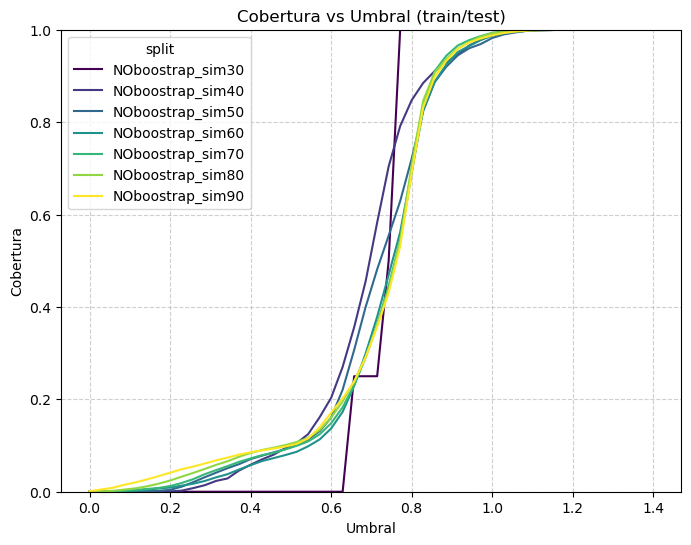

{'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim30-fold.csv': 0.0, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim40-fold.csv': 0.09735202492211838, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim50-fold.csv': 0.09607131066358535, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim60-fold.csv': 0.0828009828009828, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim70-fold.csv': 0.0952778241281495, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim80-fold.csv': 0.10385459998928782, 'archiveII_similars_splits_less_than_512_k10_NOboostrap_sim90-fold.csv': 0.10049391260578223}


In [14]:
thresholds = np.linspace(0, 1.4, 50) 

plt.figure(figsize=(8, 6))
cover_metric = {}
for i, split in enumerate(splits_list):
    mat = dfs[split]['train']['test']
    vals_dist = mat.values.ravel()
    cover_metric[split] = (vals_dist <= 0.5).mean().item()
    coverage = [(vals_dist <= t).mean() for t in thresholds]
    plt.plot(
        thresholds,
        coverage,
        label=f"{split[44:-9]}",
        color=colors[i]
    )

plt.title("Cobertura vs Umbral (train/test)")
plt.xlabel("Umbral")
plt.ylabel("Cobertura")
plt.grid(True, ls="--", alpha=0.6)
plt.ylim(0, 1)
plt.legend(title="split")
plt.savefig(save_path+"coverage.pdf")

plt.show()
print(cover_metric)